<a href="https://colab.research.google.com/github/DL4CV-NPTEL/2026/blob/main/notebooks/Week%202/Week_2_Lecture_7_New.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📺 [Lecture video](https://www.youtube.com/watch?v=WP6Viubo5b8) &nbsp;|&nbsp; 📄 [Slides](https://github.com/DL4CV-NPTEL/2026/blob/main/Slides/Week%202/DL4CV_Week02_Part07.pdf)

In [1]:
# Week 2, Lecture 7: Human Visual System
from IPython.display import HTML, display

VIDEO_ID = "WP6Viubo5b8"

# YouTube's official embed markup. The `allow` list delegates the permissions the
# player needs; Colab renders outputs inside a nested iframe and without that
# delegation the player aborts with "Error 153".
display(HTML(f"""
<iframe width="720" height="405"
        src="https://www.youtube.com/embed/{VIDEO_ID}"
        title="YouTube video player" frameborder="0"
        allow="accelerometer; autoplay; clipboard-write; encrypted-media; gyroscope; picture-in-picture; web-share"
        referrerpolicy="strict-origin-when-cross-origin"
        allowfullscreen></iframe>
<p><a href="https://www.youtube.com/watch?v={VIDEO_ID}" target="_blank">Watch on YouTube</a></p>
"""))

# Week 2, Lecture 7: Human Visual System

**NPTEL Deep Learning for Computer Vision** | Prof. Vineeth N Balasubramanian, IIT Hyderabad

Companion notebook for **§2.7 Human Visual System**.

**What you will learn**

- Relate visible light and the solar spectrum to what the eye actually samples.
- Understand **rods, cones and trichromatic coding**.
- See **center-surround receptive fields**, and use them to explain the **Hermann grid** illusion.
- Understand temporal filtering and change detection.
- Connect **simple cells** and direction selectivity to the oriented filters learned from natural images.

**Contents**
1. Visible light and the solar spectrum
2. Rods, cones, and trichromatic coding
3. Center-surround receptive fields
4. The Hermann grid illusion
5. Temporal filtering and change detection
6. Simple cells and direction selectivity
7. Oriented filters from natural images

**How to run**  Runs on Colab or a local Jupyter, CPU only. Needs `scikit-learn` alongside `scikit-image` and `scipy`; Colab ships all three. Run the setup cell first, then go top to bottom.

## Review

Previous lectures built hand-crafted detectors and descriptors. This lecture steps back to the system those methods were quietly imitating: the human visual system. The pathway runs

$$ \text{retina} \;\to\; \text{optic nerve} \;\to\; \text{LGN} \;\to\; \text{V1} \;\to\; \text{higher cortex (V2, V4, MT, ...)} $$

and splits into a *ventral* "what" stream for object identity and a *dorsal* "where" stream for location and motion.

One idea recurs at every stage: the visual system computes **derivatives**. The retina and LGN take spatial and temporal derivatives with center-surround filters; V1 simple cells take *oriented* spatial derivatives; motion-selective cells take oriented derivatives in space and time. Strikingly, when we instead ask an algorithm to find an efficient code for natural images, it discovers the very same oriented, localized filters. This notebook rebuilds these operations in code.


## Setup

Everything runs offline on images bundled with `scikit-image` or generated synthetically. The `load_gray` and `show` helpers are shared across sections.


In [2]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import ndimage as ndi
from skimage import data, util, color
from skimage.filters import gabor_kernel
from sklearn.decomposition import FastICA

np.random.seed(0)
plt.rcParams['figure.figsize'] = (10, 4)
plt.rcParams['image.cmap']     = 'gray'
plt.rcParams['figure.dpi']     = 85

def load_gray(image):
    return color.rgb2gray(image) if image.ndim == 3 else util.img_as_float(image)

def show(ax, im, title='', cmap='gray'):
    ax.imshow(im, cmap=cmap); ax.set_title(title); ax.axis('off')


## 1. Visible Light and the Solar Spectrum

Human vision uses a narrow slice of the electromagnetic spectrum, roughly 400 to 700 nm. That slice is not arbitrary: it is where the Sun deposits most of its energy. A hot body radiates with a spectrum given by **Planck's law**,

$$ B(\lambda, T) \;=\; \frac{2 h c^2}{\lambda^5} \, \frac{1}{\exp\!\left(\dfrac{h c}{\lambda k_B T}\right) - 1} , $$

and the wavelength of peak emission follows **Wien's displacement law**,

$$ \lambda_{\text{peak}} \;=\; \frac{b}{T}, \qquad b \approx 2.898 \times 10^{-3}\ \text{m} \cdot \text{K} . $$

For the Sun ($T \approx 5778$ K) the peak lands inside the visible band; for the Earth ($T \approx 300$ K) it sits far out in the infrared.


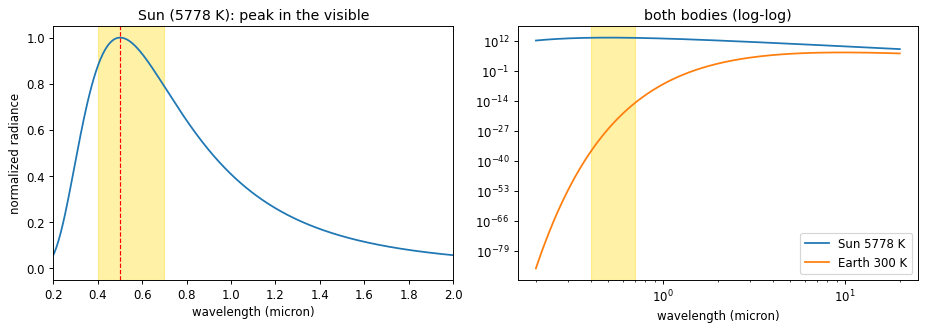

Sun   peak (Wien): 502 nm    (visible)
Earth peak (Wien): 9.7 micron (far infrared)


In [3]:
h, c, kB = 6.62607015e-34, 2.99792458e8, 1.380649e-23
def planck(wl_m, T):                                  # spectral radiance vs wavelength
    return 2*h*c**2 / wl_m**5 / (np.exp(h*c/(wl_m*kB*T)) - 1)

wl_nm = np.linspace(200, 20000, 4000)                 # 0.2 to 20 micron
wl_m  = wl_nm * 1e-9
sun, earth = planck(wl_m, 5778), planck(wl_m, 300)    # Sun ~5778 K, Earth ~300 K
b = 2.897771955e-3                                    # Wien's constant (m K)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(wl_nm/1000, sun/sun.max())
ax[0].axvspan(0.4, 0.7, color='gold', alpha=0.35)     # visible band
ax[0].axvline(b/5778*1e6, color='r', ls='--', lw=1)   # Wien peak
ax[0].set(xlim=(0.2, 2), xlabel='wavelength (micron)', ylabel='normalized radiance',
          title='Sun (5778 K): peak in the visible')
ax[1].loglog(wl_nm/1000, sun,   label='Sun 5778 K')
ax[1].loglog(wl_nm/1000, earth, label='Earth 300 K')
ax[1].axvspan(0.4, 0.7, color='gold', alpha=0.35)
ax[1].set(xlabel='wavelength (micron)', title='both bodies (log-log)'); ax[1].legend()
plt.tight_layout(); plt.show()

print('Sun   peak (Wien): %.0f nm    (visible)'    % (b/5778*1e9))
print('Earth peak (Wien): %.1f micron (far infrared)' % (b/300*1e6))


## 2. Rods, Cones, and Trichromatic Coding

The retina holds two receptor families:
- **Rods:** very sensitive to intensity, insensitive to color, and heavily pooled, so they give blurry low-light vision.
- **Cones:** less sensitive but color-selective and sharp. Three cone types (S, M, L) peak near 420, 534, and 564 nm.

Each cone reports one number, the overlap of the incoming spectrum $E(\lambda)$ with its sensitivity curve $S_k(\lambda)$:

$$ c_k \;=\; \int S_k(\lambda)\, E(\lambda)\, d\lambda, \qquad k \in \{L, M, S\} . $$

A full spectrum is effectively infinite-dimensional, but the eye collapses it to three numbers. Two physically different spectra with the same $(L, M, S)$ triple are therefore indistinguishable; such a pair is a **metamer**, and it is why a screen with only three primaries can reproduce almost any color. A later stage recombines the cones into **opponent** channels (red vs green, blue vs yellow, light vs dark), a derivative in color space that explains the complementary-colored negative afterimage.


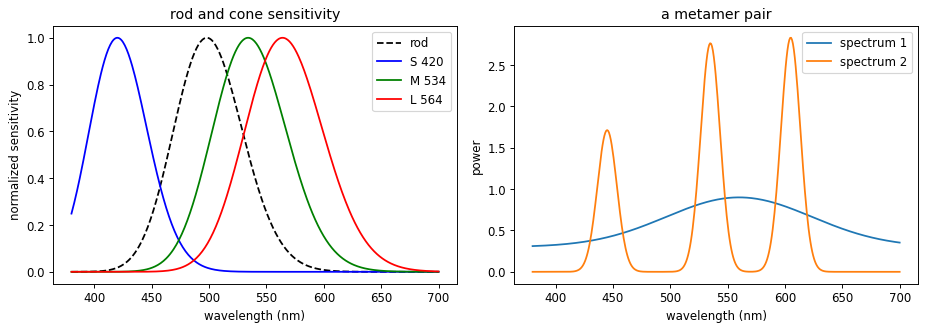

(L, M, S) for spectrum 1: [70.28 64.9  22.85]
(L, M, S) for spectrum 2: [70.28 64.9  22.85]
same to the eye, different physically: True


In [4]:
def sensitivity(wl, peak, width=0.06):                # log-Gaussian receptor sensitivity
    return np.exp(-(np.log(wl/peak))**2 / (2*width**2))

trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz   # NumPy 2.0 renamed trapz

wl = np.linspace(380, 700, 400)
S, M, L, rod = (sensitivity(wl, p) for p in (420, 534, 564, 498))

def cone_response(E):                                 # spectrum -> (L, M, S)
    return np.array([trapz(E*L, wl), trapz(E*M, wl), trapz(E*S, wl)])

# two very different spectra that a human cannot tell apart (a metamer pair)
E1   = 0.6*np.exp(-((wl-560)/90)**2) + 0.3            # smooth broadband
band = lambda mu: np.exp(-((wl-mu)/12)**2)            # a narrow spectral line
basis = np.vstack([cone_response(band(m)) for m in (535, 605, 445)]).T
w = np.linalg.solve(basis, cone_response(E1))         # match (L,M,S) with three lines
E2 = w[0]*band(535) + w[1]*band(605) + w[2]*band(445)

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for curve, name, col, style in [(rod,'rod','k','--'), (S,'S 420','b','-'),
                                (M,'M 534','g','-'), (L,'L 564','r','-')]:
    ax[0].plot(wl, curve, col, ls=style, label=name)
ax[0].set(xlabel='wavelength (nm)', ylabel='normalized sensitivity',
          title='rod and cone sensitivity'); ax[0].legend()
ax[1].plot(wl, E1, label='spectrum 1'); ax[1].plot(wl, E2, label='spectrum 2')
ax[1].set(xlabel='wavelength (nm)', ylabel='power', title='a metamer pair'); ax[1].legend()
plt.tight_layout(); plt.show()

print('(L, M, S) for spectrum 1:', cone_response(E1).round(2))
print('(L, M, S) for spectrum 2:', cone_response(E2).round(2))
print('same to the eye, different physically:',
      np.allclose(cone_response(E1), cone_response(E2)))


## 3. Center-Surround Receptive Fields as a Difference of Gaussians

A retinal ganglion cell (and later an LGN cell) responds to a small disc of the image, its **receptive field**. An on-center cell is excited by light in the center and inhibited by light in the surrounding ring; an off-center cell does the reverse. This profile is well modeled by a **Difference of Gaussians**,

$$ \text{DoG}(x, y) \;=\; \frac{1}{2\pi\sigma_c^2}\, e^{-\frac{x^2+y^2}{2\sigma_c^2}} \;-\; \frac{1}{2\pi\sigma_s^2}\, e^{-\frac{x^2+y^2}{2\sigma_s^2}}, \qquad \sigma_s > \sigma_c , $$

which closely approximates the **Laplacian of a Gaussian** $\nabla^2 h_\sigma$ from the slides when $\sigma_s / \sigma_c \approx 1.6$. Because the kernel sums to zero, it ignores flat regions and fires only where intensity changes. That is a spatial derivative: the retina is edge-detecting before the signal ever leaves the eye.


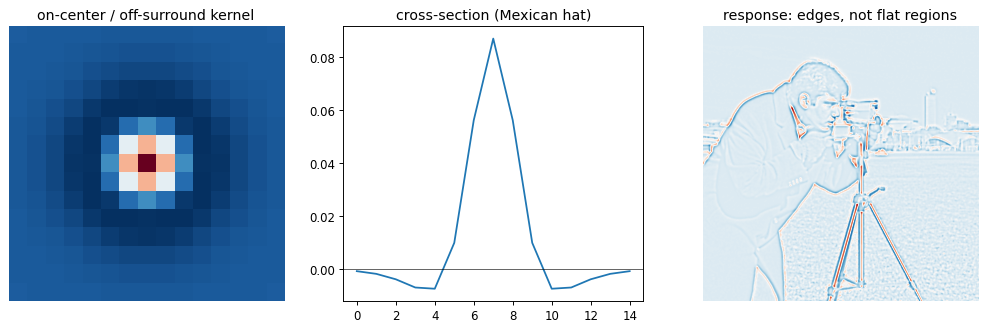

kernel sum (response to a flat field): 6.94e-17


In [5]:
def dog(sigma_c, sigma_s, size=None):                 # on-center / off-surround kernel
    if size is None: size = int(6*sigma_s) | 1
    ax = np.arange(size) - size//2
    xx, yy = np.meshgrid(ax, ax)
    gauss = lambda s: np.exp(-(xx**2 + yy**2)/(2*s**2)) / (2*np.pi*s**2)
    k = gauss(sigma_c) - gauss(sigma_s)
    return k - k.mean()                               # force zero sum (no response to flat field)

k    = dog(1.2, 2.6)
im   = util.img_as_float(data.camera())
resp = ndi.convolve(im, k, mode='reflect')

fig = plt.figure(figsize=(12, 4))
show(fig.add_subplot(1, 3, 1), k, 'on-center / off-surround kernel', cmap='RdBu_r')
ax2 = fig.add_subplot(1, 3, 2)
ax2.plot(k[k.shape[0]//2]); ax2.axhline(0, color='k', lw=0.5)
ax2.set_title('cross-section (Mexican hat)')
show(fig.add_subplot(1, 3, 3), resp, 'response: edges, not flat regions', cmap='RdBu_r')
plt.tight_layout(); plt.show()

print('kernel sum (response to a flat field): %.2e' % k.sum())


## 4. The Hermann Grid Illusion

Stare at a grid of black squares separated by white streets and faint dark blobs appear at the crossings, vanishing when you look straight at them. The center-surround model from the previous section explains it directly. For an on-center cell sitting on a white street:
1. At a point midway along a street, the inhibitory surround overlaps two white arms and two black squares.
2. At a crossing, the surround overlaps four white arms, so it collects more inhibition.
3. More surround inhibition means a weaker response, so crossings look darker than streets.

The illusion is not a bug; it is the visible signature of the retina taking a spatial derivative.


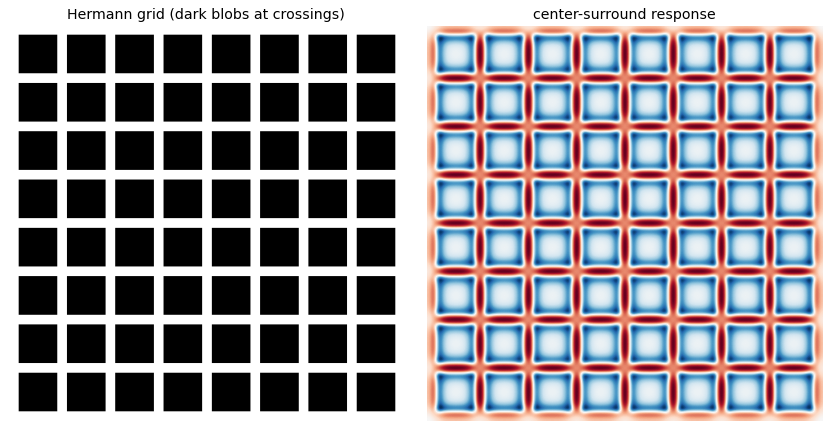

mean response at crossings: 0.204
mean response along streets: 0.402
crossings respond less, so they look darker: True


In [6]:
def hermann_grid(period=60, line=12, n=8):            # white streets over black squares
    size = period*n + line
    g = np.zeros((size, size))
    for i in range(n + 1):
        g[i*period:i*period + line, :] = 1.0
        g[:, i*period:i*period + line] = 1.0
    return g

g    = hermann_grid()
resp = ndi.convolve(g, dog(3.0, 8.0), mode='reflect')  # the retinal model from section 3

period, line, crossings, streets = 60, 12, [], []
for i in range(1, 7):
    for j in range(1, 7):
        r0 = i*period + line//2
        crossings.append(resp[r0, j*period + line//2])    # a street crossing
        streets.append(  resp[r0, j*period + period//2])  # midway along a street
crossings, streets = np.mean(crossings), np.mean(streets)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
show(ax[0], g, 'Hermann grid (dark blobs at crossings)')
show(ax[1], resp, 'center-surround response', cmap='RdBu_r')
plt.tight_layout(); plt.show()

print('mean response at crossings: %.3f' % crossings)
print('mean response along streets: %.3f' % streets)
print('crossings respond less, so they look darker:', crossings < streets)


## 5. Temporal Filtering: Detecting Change

The same cells filter in time as well as space. The temporal receptive field is **biphasic**: a positive lobe peaking near 25 ms followed by a negative lobe that returns to zero by about 120 ms. We model it as a difference of two smooth pulses,

$$ f(t) \;=\; g(t; \tau_1, n_1) \;-\; \kappa\, g(t; \tau_2, n_2), \qquad g(t; \tau, n) = \left(\tfrac{t}{\tau}\right)^{n} e^{-n(t/\tau - 1)} . $$

The weight $\kappa$ is chosen so the filter integrates to zero. A zero-integral filter ignores a steady light and responds only to changes,

$$ r(t) \;=\; (f * I)(t) \;\approx\; \frac{dI}{dt} , $$

which is why a ganglion cell fires a burst when a light switches on and falls quiet while it stays on. This is a temporal derivative, the time analogue of the center-surround.


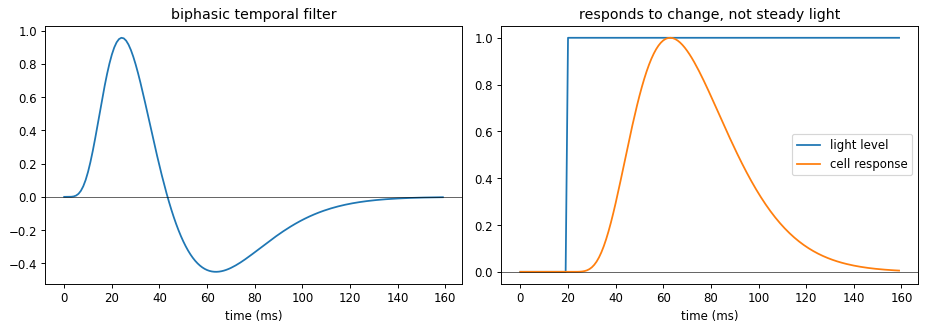

filter integral (near zero => change detector): 0.000
positive peak at 24 ms, negative lobe at 64 ms


In [7]:
t = np.arange(0, 160, 1.0)                            # milliseconds
def bump(t, t_peak, n):                               # smooth pulse peaking at t_peak
    out = np.zeros_like(t); m = t > 0
    out[m] = (t[m]/t_peak)**n * np.exp(-n*(t[m]/t_peak - 1))
    return out

pos, neg = bump(t, 25, 6), bump(t, 60, 8)
f = pos - (pos.sum()/neg.sum())*neg                   # difference of two bumps, zero integral

light = (t >= 20).astype(float)                       # light turns on and stays on
r = np.convolve(light, f, mode='full')[:len(t)]

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(t, f); ax[0].axhline(0, color='k', lw=0.5)
ax[0].set(xlabel='time (ms)', title='biphasic temporal filter')
ax[1].plot(t, light, label='light level')
ax[1].plot(t, r/np.abs(r).max(), label='cell response')
ax[1].axhline(0, color='k', lw=0.5); ax[1].legend()
ax[1].set(xlabel='time (ms)', title='responds to change, not steady light')
plt.tight_layout(); plt.show()

print('filter integral (near zero => change detector): %.3f' % f.sum())
print('positive peak at %d ms, negative lobe at %d ms' % (t[np.argmax(f)], t[np.argmin(f)]))


## 6. Simple Cells as Oriented Filters, and Direction Selectivity

In V1, **simple cells** respond to an oriented bar or edge at a specific position and orientation. Their receptive fields look like **Gabor** functions, a sinusoid inside a Gaussian window,

$$ g(x, y) \;=\; \exp\!\left(-\frac{x'^2 + \gamma^2 y'^2}{2\sigma^2}\right) \cos\!\left(2\pi \frac{x'}{\lambda} + \psi\right), \qquad \begin{aligned} x' &= x\cos\theta + y\sin\theta \\ y' &= -x\sin\theta + y\cos\theta . \end{aligned} $$

A simple cell is an *oriented* spatial derivative. **Complex cells** pool a pair of simple cells in quadrature to become invariant to the exact phase or position of the bar, which we compute as an energy,

$$ E(x, y) \;=\; \sqrt{(g_{\text{even}} * I)^2 + (g_{\text{odd}} * I)^2} . $$

The first cell below shows a bank of Gabor kernels and their orientation-selective responses.


/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: divide by zero encountered in matmul
  return rgb @ coeffs
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: overflow encountered in matmul
  return rgb @ coeffs
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/skimage/color/colorconv.py:984: RuntimeWarning: invalid value encountered in matmul
  return rgb @ coeffs


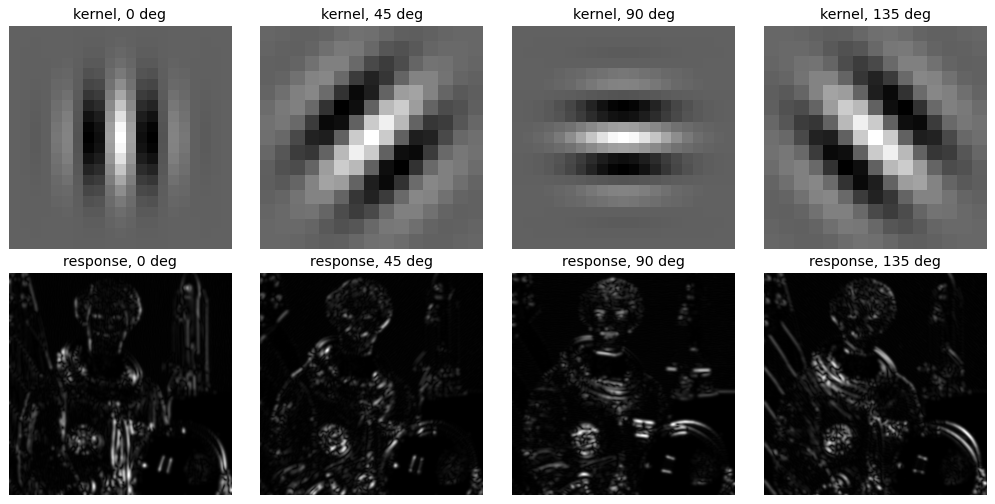

In [8]:
im = color.rgb2gray(data.astronaut())
angles = [0, 45, 90, 135]

fig, ax = plt.subplots(2, len(angles), figsize=(12, 6))
for col, deg in enumerate(angles):
    k = gabor_kernel(frequency=0.18, theta=np.deg2rad(deg))
    energy = np.sqrt(ndi.convolve(im, k.real, mode='reflect')**2 +
                     ndi.convolve(im, k.imag, mode='reflect')**2)
    show(ax[0, col], k.real,  'kernel, %d deg' % deg)
    show(ax[1, col], energy,  'response, %d deg' % deg)
plt.tight_layout(); plt.show()


The same trick works in space and time. Slice a moving bar along the $(x, t)$ plane and it becomes a slanted stripe; a Gabor oriented along that slant fires for one direction of motion but not the other. That is **direction selectivity**, an oriented derivative in $x$ and $t$.


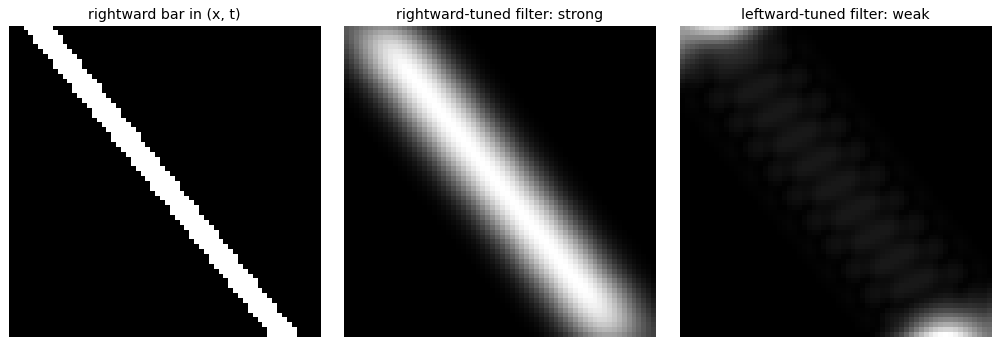

rightward bar -> rightward-filter 0.047 , leftward-filter 0.005
leftward  bar -> rightward-filter 0.005 , leftward-filter 0.047


In [9]:
def xt_bar(T=64, X=64, speed=0.8, x0=6, rightward=True, half_w=3):
    img = np.zeros((T, X))
    for time in range(T):
        center = x0 + speed*time if rightward else (X - 1 - x0) - speed*time
        c = int(round(center))
        img[time, max(0, c - half_w):c + half_w] = 1.0
    return img

def gabor_energy(img, deg, f=0.12):
    k = gabor_kernel(frequency=f, theta=np.deg2rad(deg))
    return np.sqrt(ndi.convolve(img, k.real, mode='reflect')**2 +
                   ndi.convolve(img, k.imag, mode='reflect')**2)

right, left = xt_bar(rightward=True), xt_bar(rightward=False)
fig, ax = plt.subplots(1, 3, figsize=(12, 4))
show(ax[0], right, 'rightward bar in (x, t)')
show(ax[1], gabor_energy(right, 135), 'rightward-tuned filter: strong')
show(ax[2], gabor_energy(right, 45),  'leftward-tuned filter: weak')
plt.tight_layout(); plt.show()

for name, img in [('rightward', right), ('leftward', left)]:
    er, el = gabor_energy(img, 135).mean(), gabor_energy(img, 45).mean()
    print('%-9s bar -> rightward-filter %.3f , leftward-filter %.3f' % (name, er, el))


## 7. Oriented Filters Emerge from Natural Image Statistics

Why oriented edge filters, out of all possible receptive fields? Olshausen and Field asked a purely computational question: find a small set of basis functions whose sparse linear combinations reconstruct natural image patches,

$$ \min_{\{a_i\},\, \{\phi_i\}} \; \Big\| I - \sum_i a_i \phi_i \Big\|^2 \;+\; \lambda \sum_i |a_i| . $$

The learned basis $\{\phi_i\}$ turns out to be oriented, localized, and bandpass, matching V1 simple cells even though no biology went into the objective. Below we run a close relative, **independent component analysis**, on patches drawn from a handful of natural images and recover the same kind of filters. The lesson for this course: these are essentially the features a convolutional network learns in its first layer, so the hand-crafted descriptors of earlier lectures, the primate visual cortex, and deep networks all converge on the same solution.


/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: divide by zero encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: overflow encountered in matmul
  B = (u @ vh[:rank]).conj().T
/Users/rishabh.lalla/Library/Python/3.9/lib/python/site-packages/scipy/linalg/_basic.py:1449: RuntimeWarning: invalid value encountered in matmul
  B = (u @ vh[:rank]).conj().T


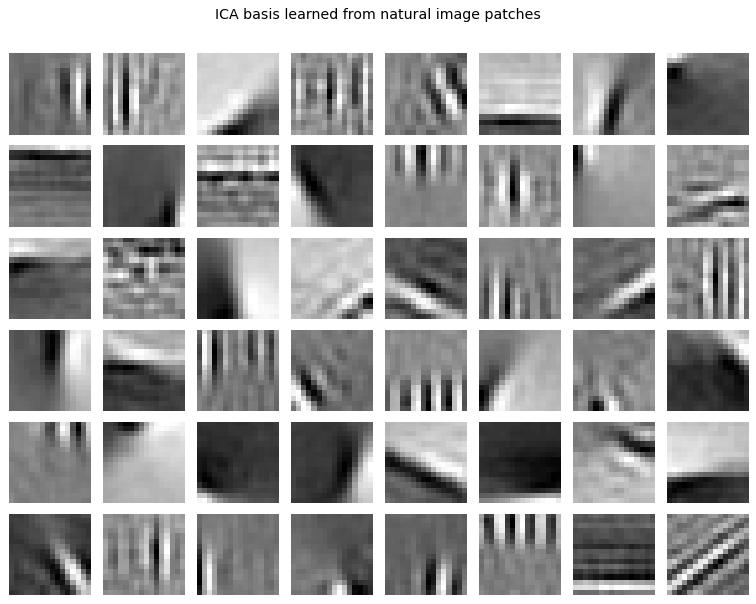

learned 64 filters from 21000 patches; most are oriented, localized, and bandpass


In [10]:
imgs = [color.rgb2gray(data.astronaut()), util.img_as_float(data.camera()),
        color.rgb2gray(data.chelsea()),   color.rgb2gray(data.coffee()),
        util.img_as_float(data.page()),   color.rgb2gray(data.rocket())]
P, per_img = 16, 3500
rng, patches = np.random.default_rng(0), []
for image in imgs:
    H, W = image.shape
    for _ in range(per_img):
        i, j = rng.integers(0, H - P), rng.integers(0, W - P)
        patches.append(image[i:i+P, j:j+P].ravel())
X = np.array(patches)
X = X - X.mean(axis=1, keepdims=True)                 # remove the brightness (DC) of each patch

ica   = FastICA(n_components=64, max_iter=500, random_state=0, whiten='unit-variance')
acts  = ica.fit_transform(X)
basis = ica.mixing_                                   # columns: learned basis functions
order = np.argsort(-acts.var(axis=0))                 # most-used filters first

fig, axes = plt.subplots(6, 8, figsize=(9, 7))
for ax, idx in zip(axes.ravel(), order[:48]):
    f = basis[:, idx].reshape(P, P)
    show(ax, (f - f.min())/(np.ptp(f) + 1e-9))
fig.suptitle('ICA basis learned from natural image patches', y=1.01)
plt.tight_layout(); plt.show()

print('learned %d filters from %d patches; most are oriented, localized, and bandpass'
      % (basis.shape[1], X.shape[0]))


## 8. Explore and verify

Two quantitative claims close this week: a centre-surround receptive field must have zero
total weight, which is exactly why it responds to contrast and not to overall brightness;
and oriented energy should peak when the filter matches the stimulus.

In [11]:
# Verify the receptive-field claims.
import scipy.ndimage as ndi

# 1. A difference-of-Gaussians sums to zero: it measures contrast, not brightness.
k = dog(2.0, 4.0, size=41)
assert abs(k.sum()) < 1e-6, f'DoG does not sum to zero: {k.sum():.2e}'

# 2. Because it sums to zero, adding a constant to the image changes nothing.
im = load_gray(data.camera())
r1 = ndi.convolve(im, k, mode='reflect')
r2 = ndi.convolve(im + 0.5, k, mode='reflect')
assert np.allclose(r1, r2, atol=1e-8), 'response changed when overall brightness changed'

# 3. Oriented energy peaks at the orientation of the stimulus.
n = 128
yy, xx = np.mgrid[0:n, 0:n]
for stim_deg in (0, 45, 90):
    stim = np.cos(2 * np.pi * 0.12 * (xx * np.cos(np.deg2rad(stim_deg)) +
                                      yy * np.sin(np.deg2rad(stim_deg))))
    energies = {d: gabor_energy(stim, d).mean() for d in range(0, 180, 15)}
    best = max(energies, key=energies.get)
    err = min(abs(best - stim_deg) % 180, 180 - abs(best - stim_deg) % 180)
    print(f'  grating at {stim_deg:3d}°  ->  strongest filter at {best:3d}°  (error {err}°)')
    assert err <= 20, f'oriented energy peaked at {best}, not {stim_deg}'

print(f'\nDoG kernel sum = {k.sum():.2e}  (zero, so it is blind to absolute brightness)')

  grating at   0°  ->  strongest filter at   0°  (error 0°)


  grating at  45°  ->  strongest filter at  45°  (error 0°)


  grating at  90°  ->  strongest filter at  90°  (error 0°)

DoG kernel sum = 1.04e-17  (zero, so it is blind to absolute brightness)


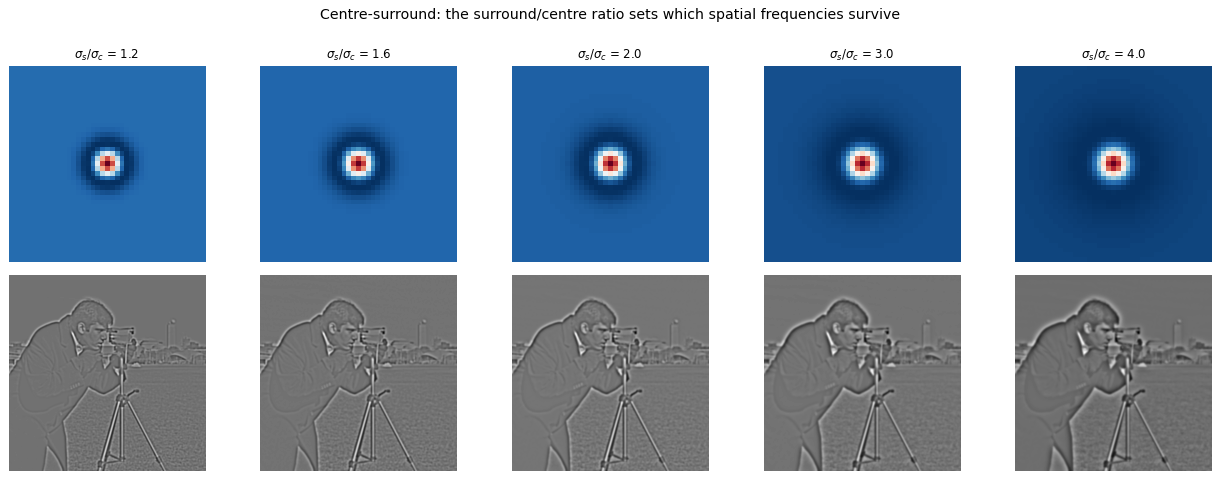

In [12]:
# Static sweep: the centre-surround ratio shapes what the cell responds to.
fig, ax = plt.subplots(2, 5, figsize=(15, 5.6))
for j, ratio in enumerate([1.2, 1.6, 2.0, 3.0, 4.0]):
    kk = dog(2.0, 2.0 * ratio, size=41)
    ax[0, j].imshow(kk, cmap='RdBu_r'); ax[0, j].set_axis_off()
    ax[0, j].set_title(f'$\sigma_s/\sigma_c$ = {ratio}', fontsize=10)
    ax[1, j].imshow(ndi.convolve(im, kk, mode='reflect'), cmap='gray'); ax[1, j].set_axis_off()
fig.suptitle('Centre-surround: the surround/centre ratio sets which spatial frequencies survive', y=1.0)
plt.tight_layout(); plt.show()

Now the same thing under your control. Drag the slider and watch what changes.

In [13]:
# Live: the centre-surround receptive field.
from ipywidgets import interact, FloatSlider

def rf(sigma_c=2.0, ratio=2.0):
    kk = dog(sigma_c, sigma_c * ratio, size=41)
    fig, ax = plt.subplots(1, 2, figsize=(9, 4.2))
    ax[0].imshow(kk, cmap='RdBu_r'); ax[0].set_title(f'DoG, sum = {kk.sum():.1e}')
    ax[1].imshow(ndi.convolve(im, kk, mode='reflect'), cmap='gray'); ax[1].set_title('response')
    for a in ax: a.set_axis_off()
    plt.tight_layout(); plt.show()

interact(rf, sigma_c=FloatSlider(min=0.5, max=6, step=0.5, value=2.0),
             ratio=FloatSlider(min=1.2, max=5.0, step=0.2, value=2.0));

interactive(children=(FloatSlider(value=2.0, description='sigma_c', max=6.0, min=0.5, step=0.5), FloatSlider(v…

---

## Key takeaways

| Stage | Operation | Model in code |
|---|---|---|
| Sun and eye | vision tuned to the solar peak | Planck's law, Wien's law |
| Cones | full spectrum collapsed to three numbers | inner product with S, M, L curves; metamers |
| Retina, LGN | spatial derivative (edges) | Difference of Gaussians, zero sum |
| Retina, LGN | temporal derivative (change) | biphasic zero-integral filter |
| V1 simple cells | oriented spatial derivative | Gabor filters |
| V1 complex, MT | phase invariance, motion | quadrature energy, space-time Gabor |
| Learning | oriented filters are the efficient code | ICA on natural patches |

**Reading:** Lecture 8 of R. Rao's CS455 (UWashington, 2009). Hubel, *Eye, Brain, and Vision*. Olshausen and Field, "Emergence of simple-cell receptive field properties by learning a sparse code for natural images", Nature 1996. Rao and Ballard, "Predictive coding in the visual cortex", Nature Neuroscience 1999.

**To think about:**
- Center-surround, Gabor, and space-time filters are all derivatives at different scales and orientations. What does a convolutional network's first layer look like, and why might it rediscover them?
- Trichromacy discards almost all spectral detail yet we rarely notice. What visual tasks would a hyperspectral eye do better?
- Complex cells gain position invariance by pooling simple cells in quadrature. Which modern network component plays the same role?


## Exercises

1. **Construct a metamer.** Find two different spectra whose inner products with the S, M and L curves are identical. Explain why colour reproduction is possible at all.

2. **Why the Hermann grid works.** Confirm your difference-of-Gaussians kernel sums to zero, then apply it to the grid and show where the illusory dark spots come from.

3. **Fit a Gabor to a simple cell.** Choose an orientation and frequency, build the Gabor, and show it responds selectively to a matching grating and weakly to an orthogonal one.

4. **Oriented filters are learned, not designed.** Run ICA on patches from natural images and compare the recovered basis with the Gabor filters you built by hand.